# Yet Another Tips Dataset Analysis

My stab at the ever-popular tips database.

## Data import and exploration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
%matplotlib inline

In [2]:
tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


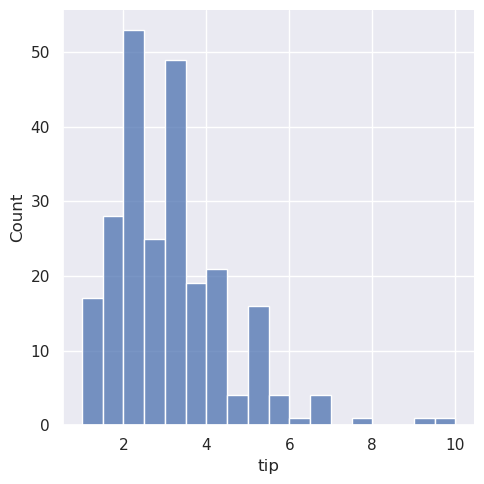

In [5]:
sns.displot(x='tip',data=tips)

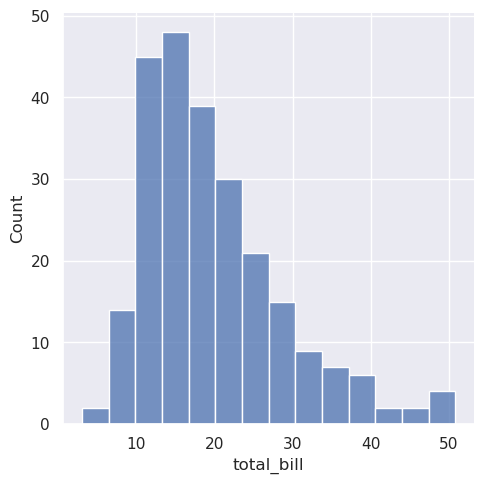

In [6]:
sns.displot(x='total_bill',data=tips)

These don't look normally distributed. They seem right-tailed.

In [7]:
stats.skew(tips['total_bill'])

np.float64(1.1262346334818638)

In [8]:
stats.skew(tips['tip'])

np.float64(1.4564266884221506)

Yep, they're both right-tailed.

Now let's look at scatterplots.

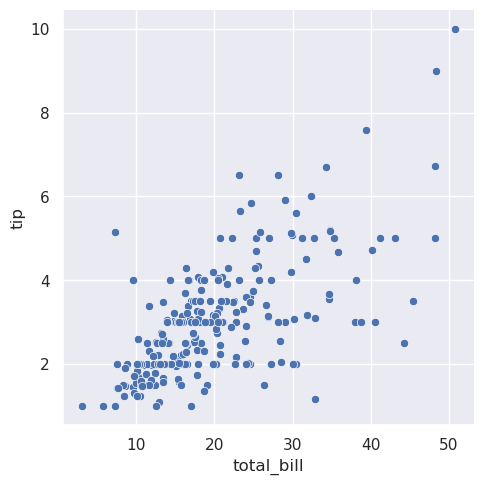

In [9]:
sns.relplot(x='total_bill',y='tip',data=tips)

<Axes: xlabel='total_bill', ylabel='tip'>

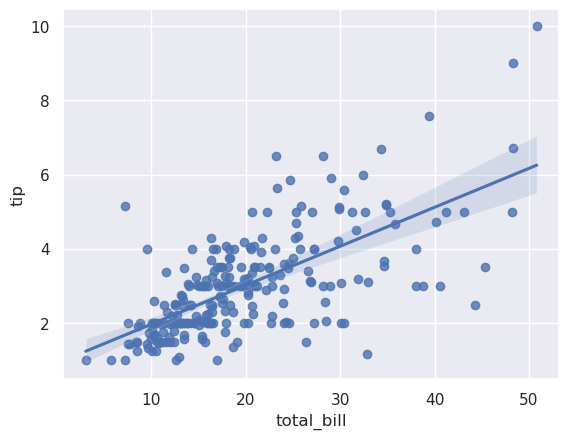

In [10]:
sns.regplot(x='total_bill',y='tip',data=tips)

In [11]:
results = smf.ols('tip ~ total_bill',data=tips).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           6.69e-34
Time:                        11:05:56   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9203      0.160      5.761      0.000       0.606       1.235
total_bill     0.1050      0.007     14.260      0.000       0.091       0.120
==============================================================================
Omnibus:                       20.185   Durbin-Watson:                   2.151
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.750
Skew:                           0.443   Prob(JB):                     6.35e-09
Kurtosis:                       4.711   Cond. No.                         53.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='total_bill', ylabel='tip'>

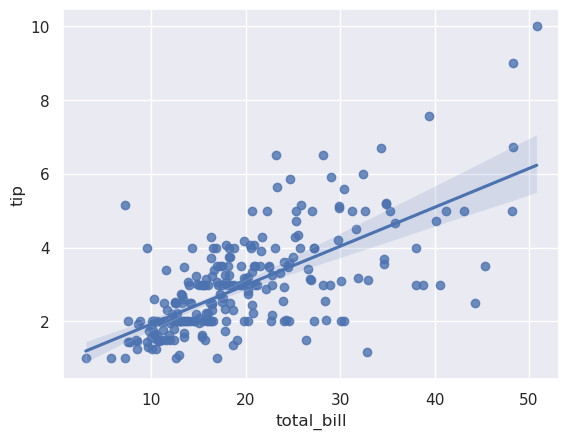

In [12]:
sns.regplot(x='total_bill',y='tip',robust=True,data=tips)

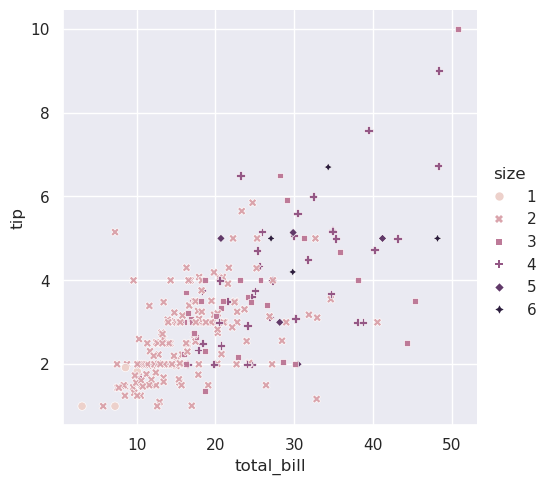

In [13]:
sns.relplot(x='total_bill',y='tip',hue='size',style='size',data=tips)

## Data modeling

Let's try a formal regression of tip vs. total bill and the party size.

In [14]:
results = smf.ols('tip ~ total_bill + size',data=tips).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           9.67e-34
Time:                        11:06:04   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6689      0.194      3.455      0.001       0.288       1.050
total_bill     0.0927      0.009     10.172      0.000       0.075       0.111
size           0.1926      0.085      2.258      0.025       0.025       0.361
==============================================================================
Omnibus:                       24.753   Durbin-Watson:                   2.100
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.169
Skew:                           0.545   Prob(JB):                     9.43e-11
Kurtosis:                       4.831   Cond. No.                         67.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Seems like a pretty good fit, but the total bill seems to have the biggest influence, based on the t statistic and p-value.

In [15]:
results.resid.describe()

count    2.440000e+02
mean    -4.965063e-15
std      1.009327e+00
min     -2.927919e+00
25%     -5.547113e-01
50%     -8.524018e-02
75%      5.094983e-01
max      4.042497e+00
dtype: float64

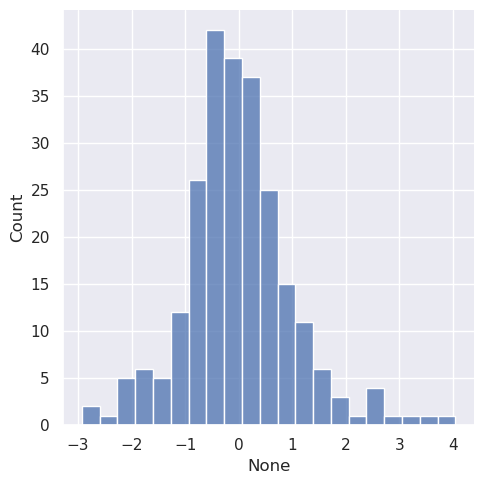

In [16]:
sns.displot(x=results.resid)

The residual distribution seems to be mostly normal.

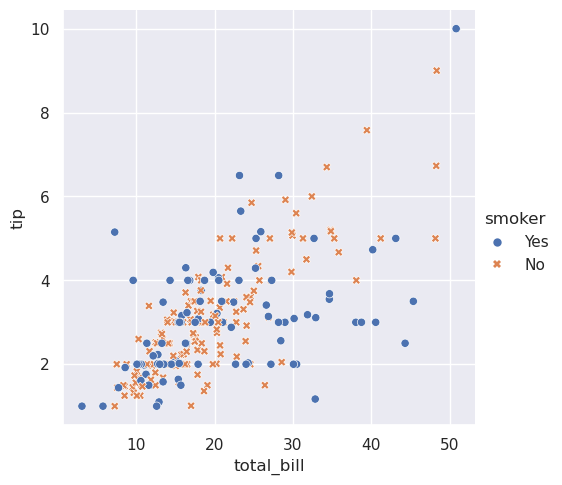

In [17]:
sns.relplot(x='total_bill',y='tip',hue='smoker',style='smoker',data=tips)

Nonsmokers tend to be more generous tippers, except for one party in the upper right.

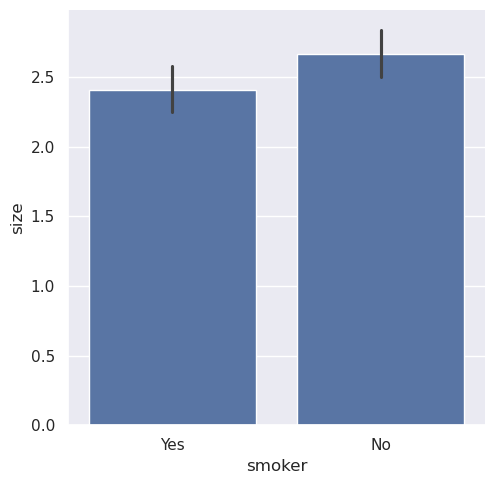

In [18]:
sns.catplot(x='smoker',y='size',kind='bar',data=tips)

Since the data is skewed as shown in the histograms, nonparametric methods seem like a better choice.

In [19]:
smoker_size = tips.loc[tips["smoker"] == "Yes","size"]
nonsmoker_size = tips.loc[tips["smoker"] == "No","size"]

stats.mannwhitneyu(smoker_size,nonsmoker_size)

MannwhitneyuResult(statistic=np.float64(6096.0), pvalue=np.float64(0.043386765553473525))

There seems to be a significant difference at the .05 level between the party size of smokers vs. nonsmokers.

In [20]:
smoker_tip = tips.loc[tips["smoker"] == "Yes","tip"]
nonsmoker_tip = tips.loc[tips["smoker"] == "No","tip"]

stats.mannwhitneyu(smoker_tip,nonsmoker_tip)

MannwhitneyuResult(statistic=np.float64(7163.0), pvalue=np.float64(0.7919240198382322))

Smoking does not seem to be a predictor of tipping.

Let's look at alternate days.

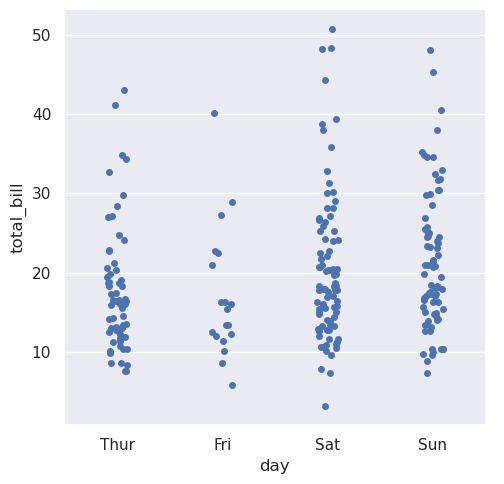

In [21]:
sns.catplot(x='day',y='total_bill',data=tips)

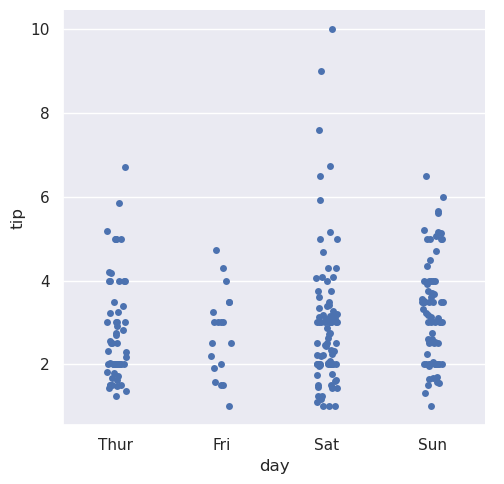

In [22]:
sns.catplot(x='day',y='tip',data=tips)

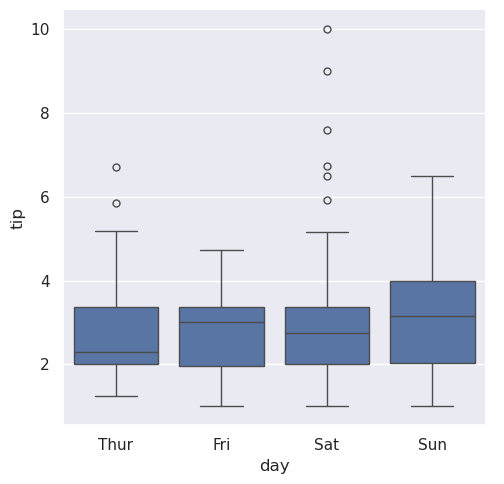

In [23]:
sns.catplot(x='day',y='tip',kind='box',data=tips)

Biggest tips are on Saturdays. Not surprising that it's a big night in hospitality. Sunday seems to have a higher median, though.

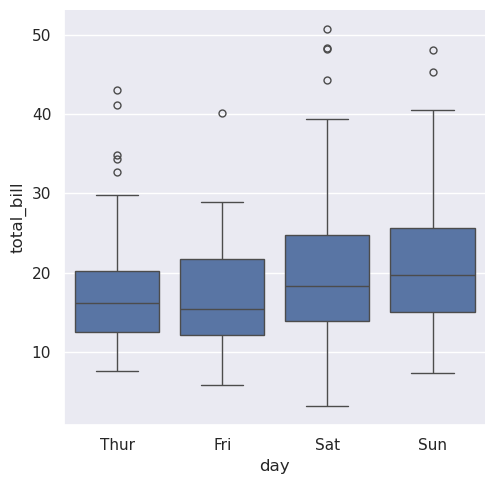

In [24]:
sns.catplot(x='day',y='total_bill',kind='box',data=tips)

In [25]:
thur_tip = tips.loc[tips["day"] == "Thur","tip"]
fri_tip = tips.loc[tips["day"] == "Fri","tip"]
sat_tip = tips.loc[tips["day"] == "Sat","tip"]
sun_tip = tips.loc[tips["day"] == "Sun","tip"]

stats.kruskal(thur_tip,fri_tip,sat_tip,sun_tip)

KruskalResult(statistic=np.float64(8.565587588927167), pvalue=np.float64(0.03566056019447427))

So tips are stastically significant at the .05 level among days.

Party size seems to have low variation. Might want to look at that.

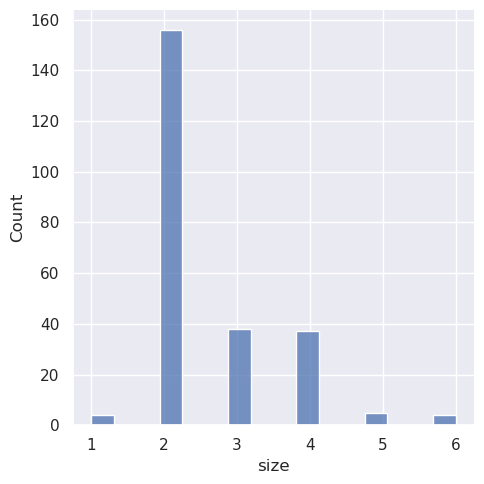

In [26]:
sns.displot(x='size',data=tips)

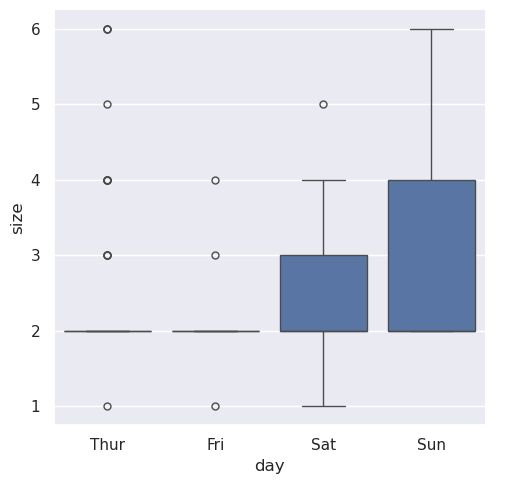

In [27]:
sns.catplot(x='day',y='size',kind='box',data=tips)

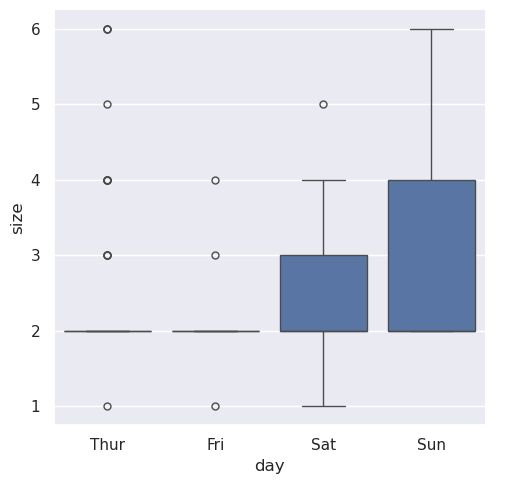

In [28]:
sns.catplot(x='day',y='size',kind='box',data=tips)

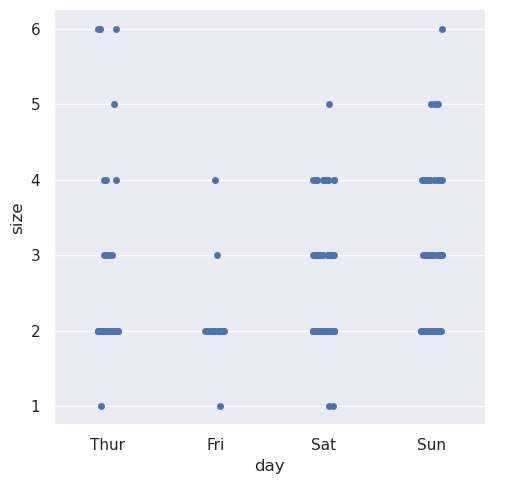

In [29]:
sns.catplot(x='day',y='size',data=tips)

Sunday seems to have larger party sizes.

In [30]:
thur_size = tips.loc[tips["day"] == "Thur","size"]
fri_size = tips.loc[tips["day"] == "Fri","size"]
sat_size = tips.loc[tips["day"] == "Sat","size"]
sun_size = tips.loc[tips["day"] == "Sun","size"]

stats.kruskal(thur_size,fri_size,sat_size,sun_size)

KruskalResult(statistic=np.float64(16.377690452129812), pvalue=np.float64(0.0009486934613152072))

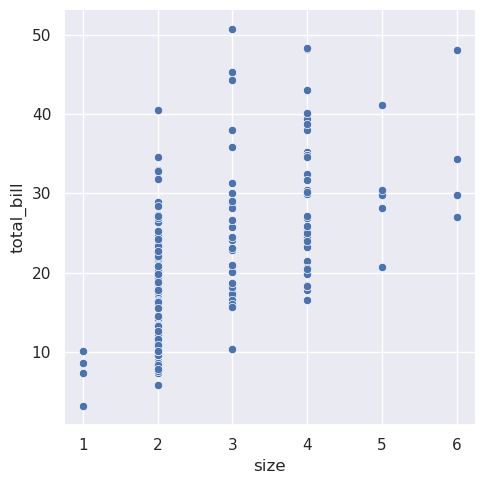

In [31]:
sns.relplot(x='size',y='total_bill',data=tips)

<Axes: xlabel='size', ylabel='total_bill'>

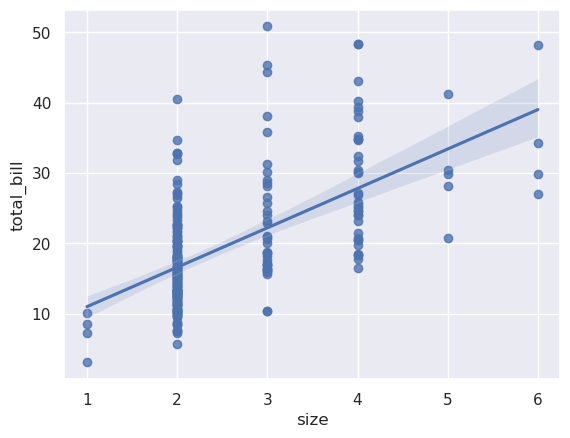

In [32]:
sns.regplot(x='size',y='total_bill',data=tips)

<Axes: xlabel='size', ylabel='tip'>

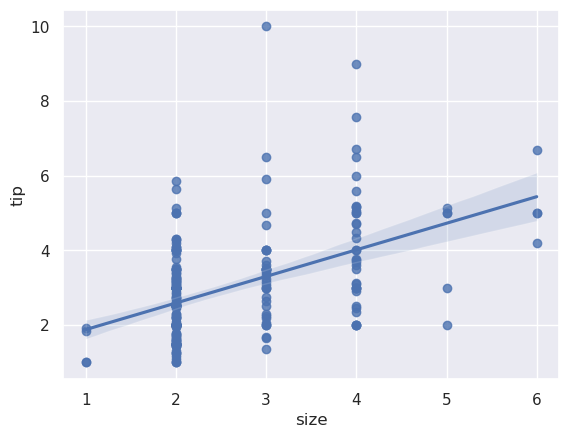

In [33]:
sns.regplot(x='size',y='tip',data=tips)

In [34]:
results = smf.ols('tip ~ size',data=tips).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     76.18
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           4.30e-16
Time:                        11:06:08   Log-Likelihood:                -391.56
No. Observations:                 244   AIC:                             787.1
Df Residuals:                     242   BIC:                             794.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1691      0.223      5.233      0.000       0.729       1.609
size           0.7118      0.082      8.728      0.000       0.551       0.872
==============================================================================
Omnibus:                       81.369   Durbin-Watson:                   1.820
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              273.339
Skew:                           1.393   Prob(JB):                     4.42e-60
Kurtosis:                       7.373   Cond. No.                         8.85
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
stats.pearsonr(tips['size'],tips['tip'])

PearsonRResult(statistic=np.float64(0.48929877523035725), pvalue=np.float64(4.300543327224998e-16))

In [36]:
results.resid

0     -1.582774
1     -1.644595
2      0.195405
3      0.717226
4     -0.406416
         ...   
239    2.615405
240   -0.592774
241   -0.592774
242   -0.842774
243    0.407226
Length: 244, dtype: float64

Pretty good correlation.

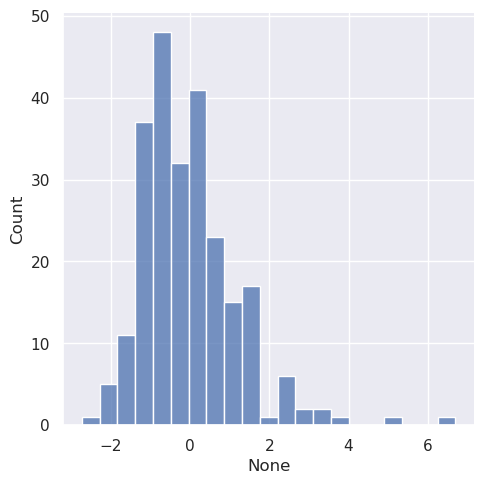

In [37]:
sns.displot(x=results.resid)

The residuals seem skewed. Let's compare a nonparametric correlation. Tips vs party size might be more like a ranking.

In [38]:
stats.spearmanr(tips['size'],tips['tip'])

SignificanceResult(statistic=np.float64(0.46826792926211475), pvalue=np.float64(1.0598503077260688e-14))

This seems to show statistical significance. With bigger party sizes on Sundays, perhaps restaurants should try running specials? I've been looking at the data for a while, and this insight surprised me.

In [39]:
stats.spearmanr(tips['size'],tips['total_bill'])

SignificanceResult(statistic=np.float64(0.6047911390994543), pvalue=np.float64(9.922307781311201e-26))

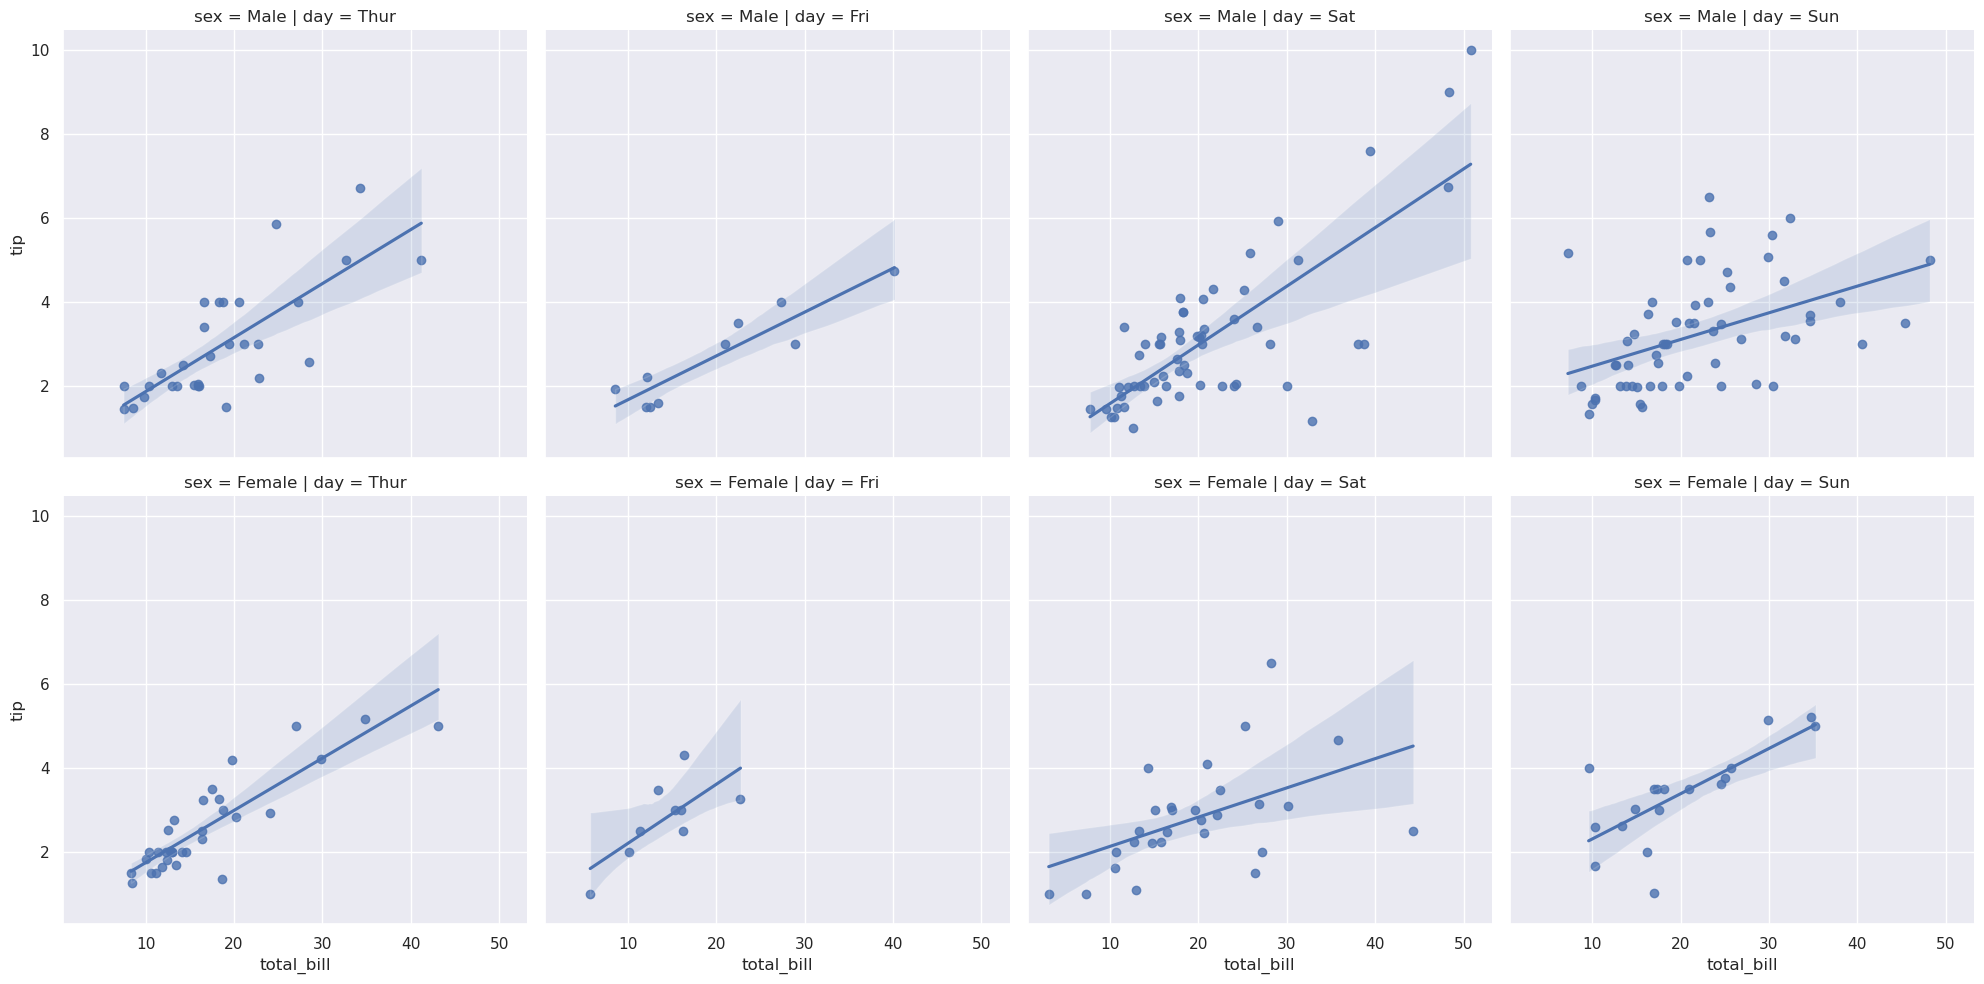

In [40]:
sns.lmplot(x='total_bill',y='tip',col='day',row='sex',data=tips)

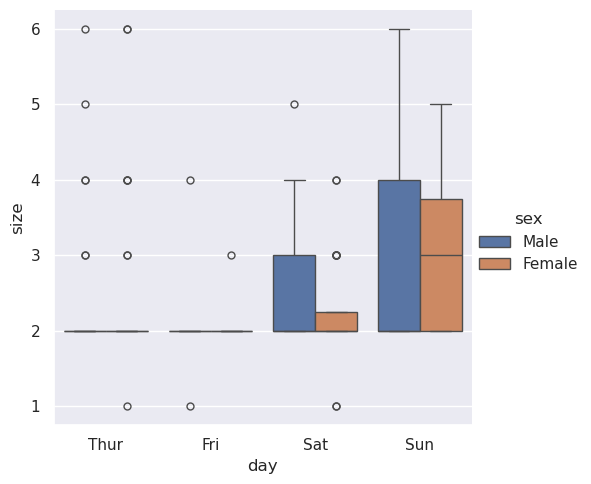

In [41]:
sns.catplot(x='day',y='size',kind='box',hue='sex',data=tips)

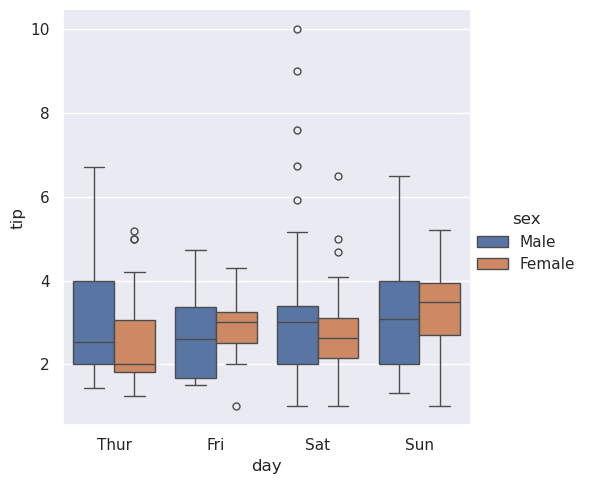

In [42]:
sns.catplot(x='day',y='tip',kind='box',hue='sex',data=tips)

There also seem to be more women on Sundays.

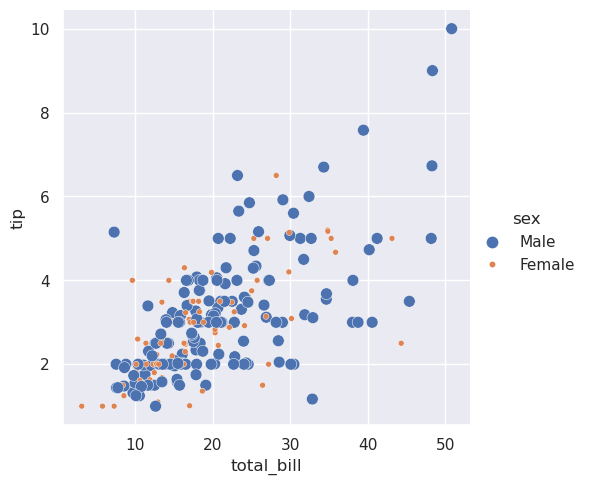

In [43]:
sns.relplot(x='total_bill',y='tip',hue='sex',size='sex',data=tips)

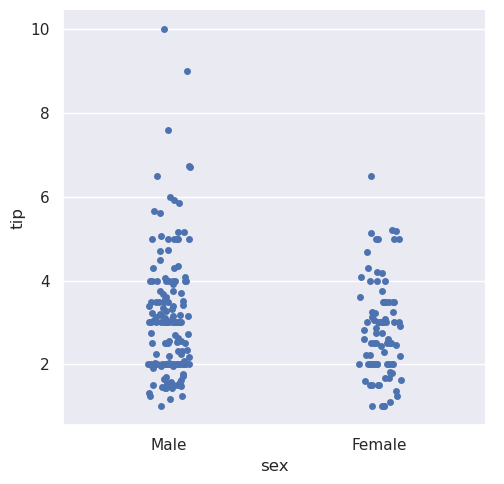

In [44]:
sns.catplot(x='sex',y='tip',data=tips)

I want to try robust regression.

In [45]:
robust_res = smf.rlm('tip ~ total_bill',data=tips).fit()
robust_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                    tip   No. Observations:                  244
Model:                            RLM   Df Residuals:                      242
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 24 Apr 2026                                         
Time:                        11:06:19                                         
No. Iterations:                    19                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8737      0.138      6.354      0.000       0.604       1.143
total_bill     0.1055      0.006     16.635      0.000       0.093       0.118
==============================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [46]:
robust_res.resid

0     -1.655685
1     -0.304304
2      0.410322
3     -0.061285
4      0.142737
         ...   
239    1.984447
240   -1.740432
241   -1.264759
242   -1.003226
243    0.145522
Length: 244, dtype: float64

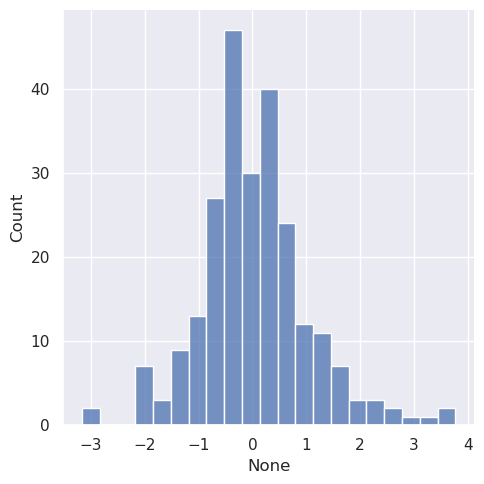

In [47]:
sns.displot(x=robust_res.resid)

That's better. The residuals seem closer to a normal distribution.

In [48]:
robust_res = smf.rlm('tip ~ total_bill + size',data=tips).fit()
robust_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                    tip   No. Observations:                  244
Model:                            RLM   Df Residuals:                      241
Method:                          IRLS   Df Model:                            2
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 24 Apr 2026                                         
Time:                        11:06:19                                         
No. Iterations:                    22                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6524      0.171      3.821      0.000       0.318       0.987
total_bill     0.0913      0.008     11.353      0.000       0.076       0.107
size           0.1938      0.075      2.576      0.010       0.046       0.341
==============================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [49]:
robust_res.resid

0     -1.580482
1     -0.517463
2      0.348832
3      0.109013
4     -0.061701
         ...   
239    2.036957
240   -1.520384
241   -1.108818
242   -0.916225
243    0.246169
Length: 244, dtype: float64

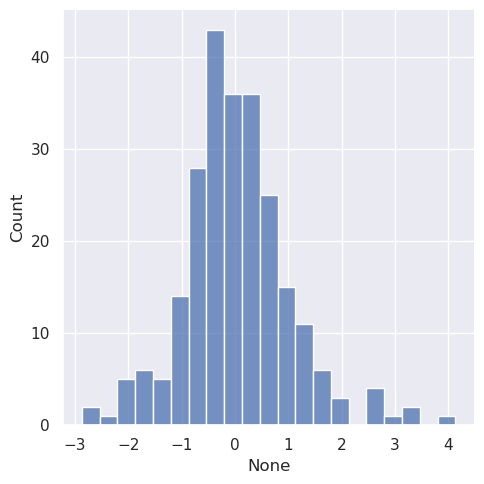

In [50]:
sns.displot(x=robust_res.resid)

Again, almost normal, but tip vs. bill seems to fit better than tip vs bill + size.

## Modeling with Scikit-learn

In [51]:
from sklearn.linear_model import LinearRegression

In [53]:
from sklearn.model_selection import train_test_split
X = tips[['total_bill']]
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y)
model = LinearRegression().fit(X_train, y_train)


In [55]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

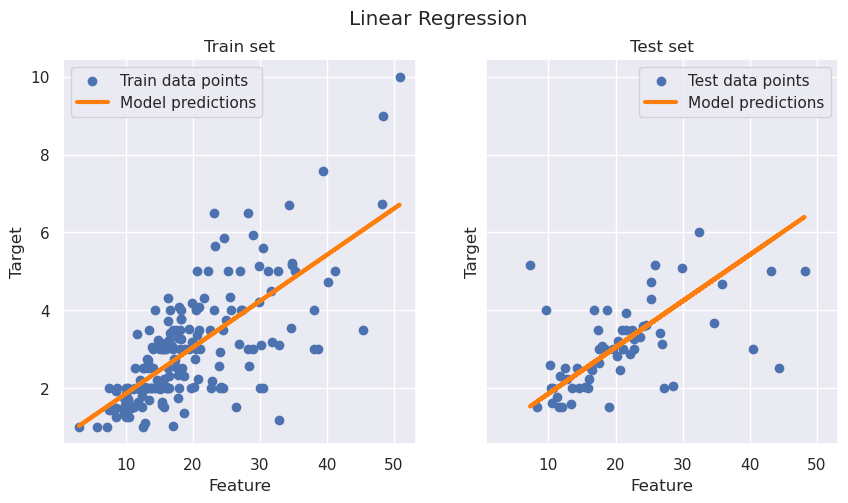

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    model.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

In [59]:
model.intercept_

np.float64(0.6610973432789966)

In [58]:
model.coef_

array([0.11901329])